# Trend of Demand

This section explores the dynamic changes in job demand over time. It includes an analysis of the monthly demand trends for key data roles and country-specific demand fluctuations, providing insights into seasonal or location-specific hiring patterns.

## Trend of Demand per Data Role

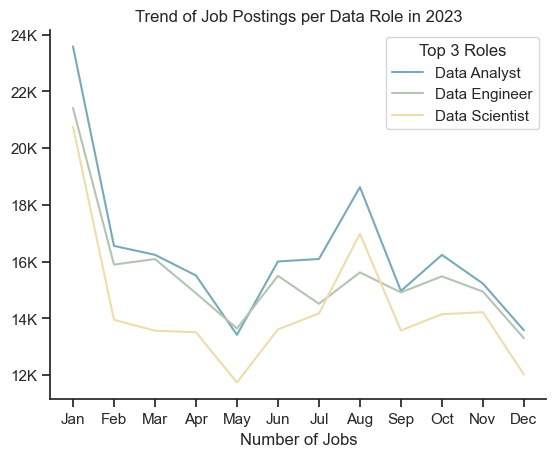

In [ ]:
# Prepare Data: Get top roles and months
top_titles = df['job_title_short'].value_counts().index[:3].to_list()  
df['job_posted_month'] = df['job_posted_date'].dt.to_period('M')      

# Build Data: Group data and change month format
df_filtered = df[df['job_title_short'].isin(top_titles)]
df_grouped = df_filtered.groupby(['job_posted_month', 'job_title_short']).size().reset_index(name='job_count')
df_grouped['job_posted_month'] = df_grouped['job_posted_month'].dt.strftime('%b')

# Data Plotting
sns.set_theme(style='ticks')
sns.lineplot(data=df_grouped, x='job_posted_month', y='job_count', hue='job_title_short', palette='blend:#7AB,#EDA')
sns.despine()

plt.title('Trend of Job Postings per Data Role in 2023')
plt.xlabel('Number of Jobs')
plt.ylabel('')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y/1000)}K'))

plt.legend(title='Top 3 Roles')
plt.show()


All data roles experience a significant spike in job postings in January, likely driven by new yearly budgets and hiring plans. However, this momentum sharply declines by February, with job postings continuing to drop until May. Data Engineers exhibit a more consistent trend during the second half of the year, indicating a stable demand for infrastructure-related roles. On the other hand, Data Analysts and Data Scientists experience another hiring surge around August, suggesting a second hiring phase, potentially driven by mid-year project expansions or performance evaluations.

## Trend of Demand of Top Skills per Data Role

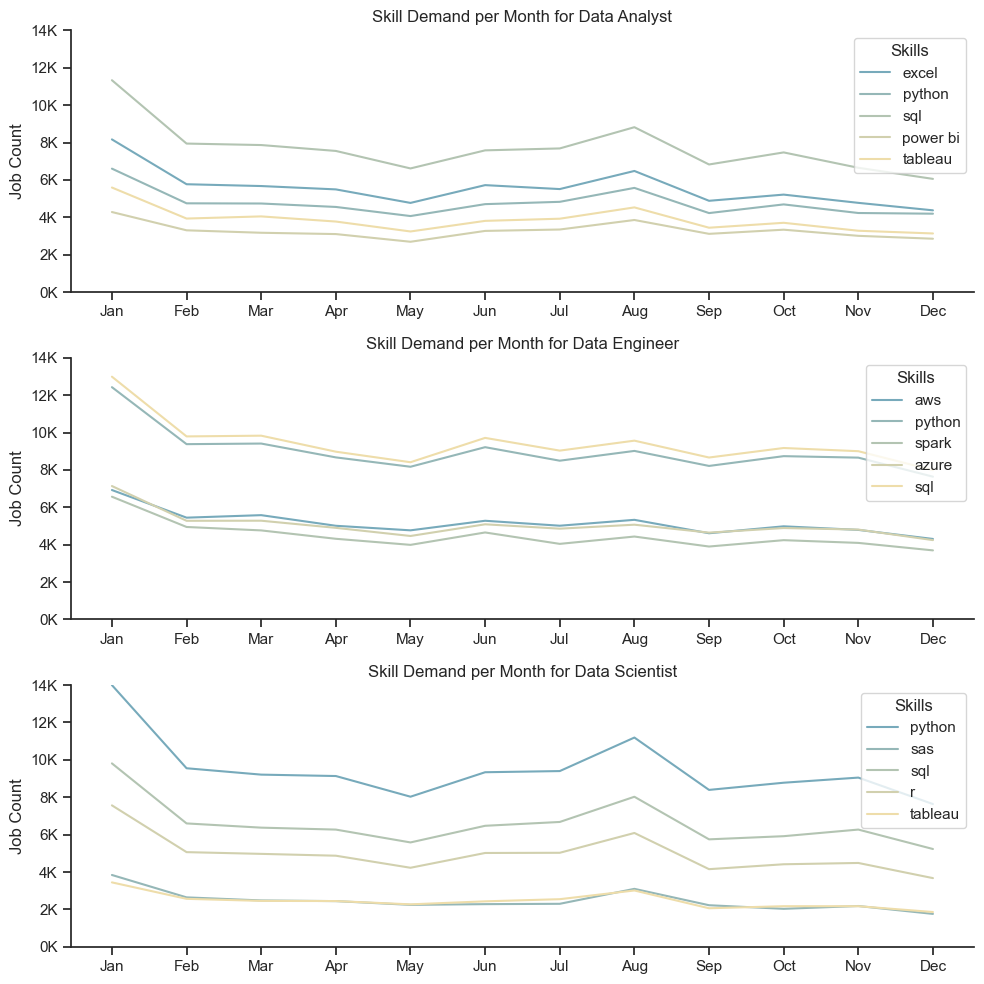

In [ ]:
# Prepare Data
df_exploded = df.explode('job_skills')
job_titles = df['job_title_short'].value_counts().index[:3].to_list()

# Plot and Visualize
fig, axes = plt.subplots(len(job_titles), 1, figsize=(10, 10))

for i, job_title in enumerate(job_titles):

    # Prepare Data: Filter according to job title and get top skills
    df_prep_skills = df_exploded[df_exploded['job_title_short'] == job_title]
    top_skills = df_prep_skills['job_skills'].value_counts().index[:5].to_list()

    # Build Data: Filter, group, and sort data and format month
    df_filtered = df_exploded[(df_exploded['job_title_short'] == job_title) & (df_exploded['job_skills'].isin(top_skills))].copy()
    df_filtered['job_posted_month'] = df_filtered['job_posted_date'].dt.to_period('M')
    df_grouped = df_filtered.groupby(['job_skills', 'job_posted_month']).size().reset_index(name='job_count')
    df_grouped = df_grouped.sort_values(by='job_posted_month')
    df_grouped['job_posted_month'] = df_grouped['job_posted_month'].dt.strftime('%b')

    # Plot
    sns.set_theme(style='ticks')
    sns.lineplot(data=df_grouped, x='job_posted_month', y='job_count', hue='job_skills', ax=axes[i], palette='blend:#7AB,#EDA')
    sns.despine()

    axes[i].set_title(f"Skill Demand per Month for {job_title}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Job Count")
    axes[i].set_ylim(0, 14000)
    axes[i].legend(title='Skills')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y/1000)}K'))

plt.tight_layout()
plt.show()

The overall demand for skills mirrors the seasonality of data roles, with no major outliers. However, a key observation is the minimal impact of data visualization tools on driving job postings, particularly in Data Science roles. For Data Analysts, while visualization tools are essential, their influence on demand remains steady and overshadowed by programming and data wrangling skills. For Data Scientists, the second peak in job postings around August is primarily driven by higher demand for programming and analytical skills (e.g., Python, SQL, R), whereas demand for visualization (Tableau) and highly complex modeling (SAS) remain flat.

## Trend of Demand of Data Jobs Across Different Countries 

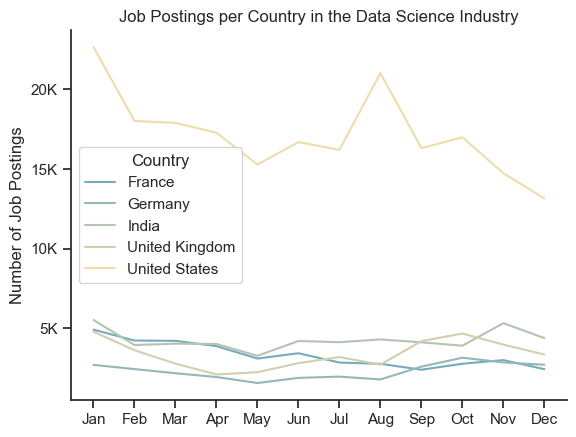

In [ ]:
# Prepare Data: Gets months and top countries
df['job_posted_month'] = df['job_posted_date'].dt.to_period('M') 
top_5_countries = df['job_country'].value_counts().index[:5].to_list()

# Build Data: Groups data and formats the month
df_filtered = df[df['job_country'].isin(top_5_countries)]
df_grouped = df_filtered.groupby(['job_country', 'job_posted_month']).size().reset_index(name='job_count')
df_grouped['job_posted_month'] = df_grouped['job_posted_month'].dt.strftime('%b')

# Plot and Visualize
sns.set_theme(style='ticks')
sns.lineplot(data=df_grouped, x='job_posted_month', y='job_count', hue='job_country', palette='blend:#7AB,#EDA')
sns.despine()

plt.title('Job Postings per Country in the Data Science Industry')
plt.xlabel('')
plt.ylabel('Number of Job Postings')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y/1000)}K'))

plt.legend(title='Country')
plt.show()

The overall job posting trend is heavily influenced by the US, which drives major surges at both the beginning and middle of the year. However, other countries exhibit more consistent patterns. India, Germany, and the UK see a slight rise in job postings toward the end of the year, potentially reflecting fiscal-year-end hiring boosts or project-based recruitment cycles. On the other hand, France shows a gradual decline in job postings, potentially due to budget constraints or a slower hiring cadence.